In [1]:
from keras.datasets import mnist

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
single_image = x_train[0]

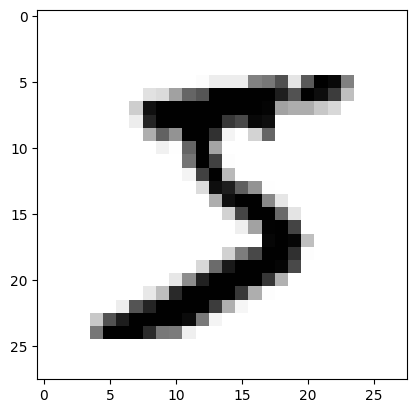

In [5]:
plt.imshow(single_image, cmap='gray_r')

In [6]:
from keras.utils import to_categorical

In [7]:
y_cat_test = to_categorical(y_test,10)
y_cat_train = to_categorical(y_train, 10)

In [9]:
# normalize image--> values in  [0,1]
x_train = x_train / x_train.max()
x_test = x_test / x_test.max()

In [10]:
x_train.shape

(60000, 28, 28)

In [11]:
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

In [12]:
# train models
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten

In [13]:
model = Sequential()

# Convolutional model
model.add(Conv2D(filters=32, kernel_size=(4,4), activation='relu', input_shape=(28,28,1)))
# Pooling layer
model.add(MaxPool2D(pool_size=(2,2)))
# 2d -> 1d
model.add(Flatten())
# Dense layer
model.add(Dense(128, activation='relu'))
# output layer
model.add(Dense(10, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

D:\Projectes\Cursos\ComputerVisionWithPython\ComputerVisionWithPythonSrc\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,786 (2.26 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.fit(x_train, y_cat_train, epochs=2)

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9591 - loss: 0.1380
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9852 - loss: 0.0482


In [16]:
model.metrics_names

['loss', 'compile_metrics']

In [18]:
model.evaluate(x_test, y_cat_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9854 - loss: 0.0390


[0.03904841095209122, 0.9854000210762024]

In [19]:
from sklearn.metrics import classification_report

In [20]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [21]:
print(classification_report(y_test, predictions))

ValueError: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets